# Handling Directories

The `os` module lets you inspect, create, rename, and delete folders.

## Listing Files
Get the current working directory and list what's inside it.

In [1]:
import os

In [2]:
os.getcwd()

'd:\\Projects\\python-for-ds-and-ai\\notebooks'

In [3]:
os.listdir()

['01_python_fundamentals.ipynb',
 '02_data_structures.ipynb',
 '03_handling_files.ipynb',
 '04_pandas.ipynb',
 '05_scikit_learn.ipynb']

In [5]:
## list the contents of a specific folder
path = '../data'
os.listdir(path)

['mandril.png', 'penguins.csv', 'The Odyssey.txt']

## Walking a Directory Tree
`os.walk()` recursively goes through a directory and all of its subdirectories.

In [12]:
for dirpath, dirnames, filenames in os.walk('../data/'):
    print('folder:', dirpath)
    print('  subfolders:', dirnames)
    print('  files:', filenames)

folder: ../data/
  subfolders: []
  files: ['mandril.png', 'penguins.csv', 'The Odyssey.txt']


## Creating Directories
`os.mkdir()` creates a new folder. Running it twice raises a `FileExistsError`, so it's safer to check first.

In [16]:
os.mkdir('models')

In [17]:
os.path.exists('models')

True

In [18]:
## create a directory only if it doesn't already exist
path = 'models'
if not os.path.exists(path):
    os.mkdir(path)

else:
    print('It exists!')

It exists!


## Renaming Directories
`os.rename()` renames (or moves) a file or folder.

In [19]:
os.rename('models', 'MODELS')

## Deleting Directories
`os.rmdir()` removes an empty directory.

In [20]:
os.rmdir('MODELS')

## Checking Paths
`os.path` provides helpers to inspect and safely build paths.

* **exists():** Checks whether a path (file or folder) exists.
* **isdir() / isfile():** Check whether a path is a folder or a file.
* **join():** Builds a path by joining pieces, using the right separator for the OS.
* **basename() / dirname():** Split a path into its file name and its folder.

In [12]:
os.path.exists('data/')

True

In [13]:
os.path.isdir('data/')

True

In [14]:
os.path.isfile('data/')

False

In [16]:
## builds the path
os.path.join('data/', 'steve_jobs.txt')

'data/steve_jobs.txt'

In [18]:
bio_path = os.path.join('data', 'steve_jobs.txt')

print(os.path.basename(bio_path))
print(os.path.dirname(bio_path))

steve_jobs.txt
data


## Searching Files with Patterns (glob)
`glob` finds files matching a wildcard pattern instead of listing everything.

In [19]:
import glob

In [24]:
glob.glob('*.ipynb')

['01_python_fundamentals.ipynb',
 '02_data_structures.ipynb',
 '03_file_handling.ipynb']

In [18]:
glob.glob('data/*.txt')

['data\\steve_jobs.txt', 'data\\The Odyssey.txt']

# File Handling

`open()` reads or writes files. The second argument is the mode:

* **"r" - Read:** Default value. Opens a file for reading; raises an error if the file doesn't exist.
* **"w" - Write:** Opens a file for writing; creates the file if it doesn't exist, and overwrites its content if it does.
* **"a" - Append:** Opens a file for appending; creates the file if it doesn't exist, and adds content to the end.
* **"x" - Create:** Creates a new file; raises an error if the file already exists.

## Reading Files
Use `open()` to get a file object, then read its content. Prefer the `with` statement, it closes the file automatically, even if an error happens.

In [27]:
bio_path = 'data/steve_jobs.txt'

## read() returns the whole file as a single string
with open(bio_path, encoding='utf-8') as f:
    text = f.read()

print(text)

Steve Jobs

Steven Paul Jobs (February 24, 1955 - October 5, 2011) was an American entrepreneur and business magnate best known as the co-founder, chairman, and CEO of Apple Inc. He also co-founded Pixar Animation Studios and served as CEO of NeXT.

Jobs was born in San Francisco, California, and was adopted shortly after birth by Paul and Clara Jobs. In 1976, he co-founded Apple Computer with Steve Wozniak and Ronald Wayne in his parents' garage, launching the Apple I and later the Apple II, which helped popularize personal computers.

In 1985, after internal conflicts over the direction of the company, Jobs left Apple and founded NeXT, a computer platform development company. That same year, he acquired the computer graphics division of Lucasfilm, which was later renamed Pixar Animation Studios.

Apple acquired NeXT in 1997, and Jobs returned to the company he had co-founded, eventually becoming its CEO again. Under his leadership, Apple introduced the iMac, iPod, iPhone, and iPad, t

In [28]:
## readline() reads a single line at a time
with open(bio_path, encoding='utf-8') as f:
    first_line = f.readline()

print(first_line)

Steve Jobs



In [31]:
## readlines() returns a list with every line in the file
with open(bio_path, encoding='utf-8') as f:
    lines = f.readlines()
    
print(lines)
print(len(lines), 'lines')

['Steve Jobs\n', '\n', 'Steven Paul Jobs (February 24, 1955 - October 5, 2011) was an American entrepreneur and business magnate best known as the co-founder, chairman, and CEO of Apple Inc. He also co-founded Pixar Animation Studios and served as CEO of NeXT.\n', '\n', "Jobs was born in San Francisco, California, and was adopted shortly after birth by Paul and Clara Jobs. In 1976, he co-founded Apple Computer with Steve Wozniak and Ronald Wayne in his parents' garage, launching the Apple I and later the Apple II, which helped popularize personal computers.\n", '\n', 'In 1985, after internal conflicts over the direction of the company, Jobs left Apple and founded NeXT, a computer platform development company. That same year, he acquired the computer graphics division of Lucasfilm, which was later renamed Pixar Animation Studios.\n', '\n', 'Apple acquired NeXT in 1997, and Jobs returned to the company he had co-founded, eventually becoming its CEO again. Under his leadership, Apple intr

## Writing Files
`'w'` mode creates the file if needed and overwrites whatever content was there before.

In [32]:
copy_path = 'data/steve_jobs_copy.txt'

with open(copy_path, 'w', encoding='utf-8') as f:
    f.write('This is a working copy for practice.\n')

with open(copy_path, encoding='utf-8') as f:
    print(f.read())

This is a working copy for practice.



In [33]:
## writing again in 'w' mode erases the previous content
with open(copy_path, 'w', encoding='utf-8') as f:
    f.write('Now the file has different content!\n')

with open(copy_path, encoding='utf-8') as f:
    print(f.read())

Now the file has different content!



## Appending to Files
`'a'` mode adds content at the end without erasing what's already there.

In [34]:
with open(copy_path, 'a', encoding='utf-8') as f:
    f.write('This line was appended.\n')

with open(copy_path, encoding='utf-8') as f:
    print(f.read())

Now the file has different content!
This line was appended.



## Creating Files Safely
`'x'` mode is useful to avoid accidentally overwriting an existing file.

In [35]:
## the file already exists, so 'x' mode raises a FileExistsError
with open(copy_path, 'x', encoding='utf-8') as f:
    f.write('This will not be written.')

FileExistsError: [Errno 17] File exists: 'data/steve_jobs_copy.txt'

In [37]:
new_path = 'data/notes.txt'

try:
    with open(new_path, 'x', encoding='utf-8') as f:
        f.write('First time creating this file.\n')

except FileExistsError:
    print('The file already exists!')

The file already exists!


## Deleting Files
Always check a file exists before removing it, to avoid a `FileNotFoundError`.

In [38]:
## deleting a file that doesn't exist raises a FileNotFoundError
os.remove('this_file_does_not_exist.txt')

FileNotFoundError: [WinError 2] El sistema no puede encontrar el archivo especificado: 'this_file_does_not_exist.txt'

In [31]:
## delete a file only if it exists
for path in (copy_path, new_path):
    if os.path.exists(path):
        os.remove(path)
    else:
        print(f'{path} does not exist')

In [32]:
os.listdir('data')

['Deep Learning.pdf',
 'mandril.jpg',
 'penguins.csv',
 'steve_jobs.txt',
 'The Odyssey.txt']

# Read other files

## CSV

In [ ]:
import pandas as pd

In [11]:
df_penguins = pd.read_csv('data/penguins.csv')
df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [14]:
df_penguins.shape

(344, 8)

In [15]:
df_penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


## IMG

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

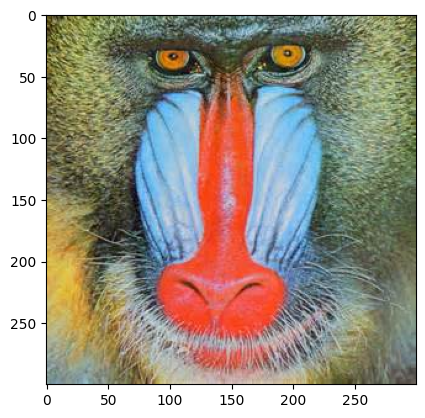

In [9]:
img = Image.open('data/mandril.jpg')

plt.imshow(img)
plt.show()

In [5]:
print(img.size)
print(img.format)
print(img.mode)

(300, 300)
JPEG
RGB


## PDF

In [19]:
#!pip install pypdf

In [20]:
from pypdf import PdfReader

In [29]:
reader = PdfReader("data/Deep Learning.pdf")

page = reader.pages[0]
text = page.extract_text()

print(text[0:1500])

1Facebook AI Research, 770 Broadway, New York, New York 10003 USA. 2New York University, 715 Broadway, New York, New York 10003, USA. 3Department of Computer Science and Operations 
Research Université de Montréal, Pavillon André-Aisenstadt, PO Box 6128  Centre-Ville STN Montréal, Quebec H3C 3J7, Canada. 4Google, 1600 Amphitheatre Parkway, Mountain View, California 
94043, USA. 5Department of Computer Science, University of Toronto, 6 King’s College Road, Toronto, Ontario M5S 3G4, Canada.
M
achine-learning technology powers many aspects of modern 
society: from web searches to content filtering on social net-
works to recommendations on e-commerce websites, and 
it is increasingly present in consumer products such as cameras and 
smartphones. Machine-learning systems are used to identify objects 
in images, transcribe speech into text, match news items, posts or 
products with users’ interests, and select relevant results of search. 
Increasingly, these applications make use of a class

In [30]:
len(reader.pages)

9